# Patient Lifestyle Phenotyping

**Objective:** Discover lifestyle phenotypes from activity, sleep, resting pulse, hydration, and stress signals for cohort exploration.

The deterministic demo data contains hidden generator profiles for post-hoc diagnostics. Those profiles are never supplied to the clustering algorithms.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Data contract and deterministic domain-shaped data


In [2]:
FEATURES = ["daily_steps", "sleep_hours", "resting_pulse", "water_liters", "active_minutes", "stress_score"]
PROFILE_CENTERS = {
  "active_balanced": [
    10500,
    7.6,
    60,
    2.6,
    72,
    30
  ],
  "sedentary_stressed": [
    3200,
    5.8,
    82,
    1.4,
    18,
    76
  ],
  "moderate": [
    7100,
    6.8,
    70,
    2.0,
    42,
    48
  ],
  "sleep_focused": [
    6200,
    8.4,
    64,
    2.3,
    35,
    24
  ]
}
rows = []
for profile, centers in PROFILE_CENTERS.items():
    centers = np.asarray(centers, dtype=float)
    scales = np.maximum(np.abs(centers) * 0.10, 0.08)
    samples = rng.normal(centers, scales, size=(125, len(FEATURES)))
    samples = np.maximum(samples, 0)
    for row in samples:
        rows.append({**dict(zip(FEATURES, row)), "generator_profile": profile})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
for column in FEATURES[:2]:
    missing_rows = rng.choice(data.index, size=8, replace=False)
    data.loc[missing_rows, column] = np.nan
print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
display(data.head().round(3))
display(data[FEATURES].describe().T.round(3))


Dataset shape: 500 rows × 7 columns


,daily_steps,sleep_hours,resting_pulse,water_liters,active_minutes,stress_score,generator_profile
0,9096.981,5.638,64.831,1.877,38.427,42.828,moderate
1,9813.003,7.925,58.865,2.685,74.606,33.962,active_balanced
2,7449.531,6.378,58.925,1.851,41.770,53.595,moderate
3,3201.925,6.060,91.556,1.631,18.557,80.481,sedentary_stressed
4,10994.693,7.195,57.530,2.954,64.508,22.762,active_balanced


,count,mean,std,min,25%,50%,75%,max
daily_steps,492.0,6671.096,2658.572,2311.042,4036.641,6643.571,8014.274,12748.730
sleep_hours,492.0,7.118,1.211,3.684,6.180,7.003,7.954,10.970
resting_pulse,500.0,68.639,10.676,46.316,60.583,67.065,75.725,102.151
water_liters,500.0,2.080,0.492,0.986,1.661,2.141,2.474,3.205
active_minutes,500.0,41.622,19.896,14.206,24.533,38.426,52.681,90.126
stress_score,500.0,44.369,20.862,18.146,26.348,35.721,59.026,91.658


## 3. Robust preprocessing and cluster-count selection


In [3]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())])
X = preprocessor.fit_transform(data[FEATURES])
selection_rows = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE).fit_predict(X)
    selection_rows.append({"k": k, "silhouette": silhouette_score(X, labels), "davies_bouldin": davies_bouldin_score(X, labels)})
selection = pd.DataFrame(selection_rows)
display(selection.round(4))
best_k = int(selection.loc[selection["silhouette"].idxmax(), "k"])
print(f"Selected k={best_k} by maximum silhouette score.")


Selected k=2 by maximum silhouette score.


,k,silhouette,davies_bouldin
0,2,0.4985,0.6614
1,3,0.4707,0.8644
2,4,0.4500,0.9095
3,5,0.4044,1.0340
4,6,0.3379,1.1670


## 4. Compare algorithms and retain the clearer solution


In [4]:
kmeans = KMeans(n_clusters=best_k, n_init=40, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X)
hierarchical_labels = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit_predict(X)

comparison = pd.DataFrame([
    {"model": "K-Means", "silhouette": silhouette_score(X, kmeans_labels), "davies_bouldin": davies_bouldin_score(X, kmeans_labels)},
    {"model": "Agglomerative", "silhouette": silhouette_score(X, hierarchical_labels), "davies_bouldin": davies_bouldin_score(X, hierarchical_labels)},
])
display(comparison.round(4))
labels = kmeans_labels if comparison.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).iloc[0]["model"] == "K-Means" else hierarchical_labels
selected_model = "K-Means" if np.array_equal(labels, kmeans_labels) else "Agglomerative"
data["cluster"] = labels
print(f"Selected solution: {selected_model}")


Selected solution: Agglomerative


,model,silhouette,davies_bouldin
0,K-Means,0.4985,0.6614
1,Agglomerative,0.5009,0.6525


## 5. Profile and visualize the discovered groups


Retrospective ARI against hidden generator profiles: 0.3320


,records,daily_steps,sleep_hours,resting_pulse,water_liters,active_minutes,stress_score
cluster,,,,,,,
0,375,7849.457,7.55,64.450,2.305,49.479,33.755
1,125,3211.429,5.81,81.203,1.407,18.051,76.210


cluster,0,1,All
generator_profile,,,
active_balanced,125,0,125
moderate,125,0,125
sedentary_stressed,0,125,125
sleep_focused,125,0,125
All,375,125,500


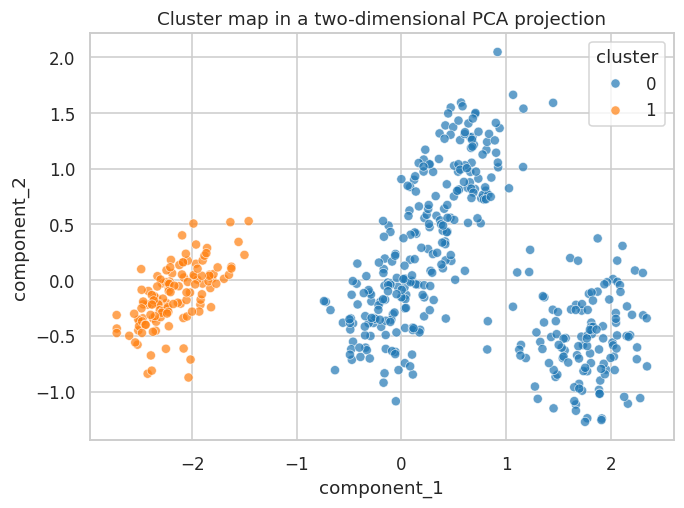

In [5]:
from sklearn.decomposition import PCA

profiles = data.groupby("cluster")[FEATURES].mean().round(3)
profiles.insert(0, "records", data.groupby("cluster").size())
display(profiles)
display(pd.crosstab(data["generator_profile"], data["cluster"], margins=True))
print(f"Retrospective ARI against hidden generator profiles: {adjusted_rand_score(data['generator_profile'], data['cluster']):.4f}")

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "cluster": data["cluster"].astype(str)})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="cluster", palette="tab10", alpha=0.7)
plt.title("Cluster map in a two-dimensional PCA projection")
plt.tight_layout()
plt.show()


## 6. Stability and assignment example


In [6]:
alternate = KMeans(n_clusters=best_k, n_init=40, random_state=7).fit_predict(X)
print(f"K-Means stability across seeds (ARI): {adjusted_rand_score(kmeans_labels, alternate):.4f}")
if selected_model == "K-Means":
    example = data[FEATURES].median().to_frame().T
    predicted = int(kmeans.predict(preprocessor.transform(example))[0])
    display(example.round(3).assign(predicted_cluster=predicted))
else:
    print("Agglomerative clustering has no native out-of-sample predict method; production assignment would use centroids or a trained surrogate.")


K-Means stability across seeds (ARI): 1.0000
Agglomerative clustering has no native out-of-sample predict method; production assignment would use centroids or a trained surrogate.


## 7. Findings and limitations

- Multiple internal metrics and a seed-stability check are used because clustering has no single accuracy measure.
- Hidden generator profiles provide only a retrospective pipeline check.
- Production interpretation requires domain validation, drift monitoring, and explicit rules for acting on segments.
